In [ ]:
# ============================================
# 02 - REPRESENTACIÓN DE DATOS PARA DEEP LEARNING
# Proyecto: Clasificación de radiografías NORMAL vs PNEUMONIA
# ============================================

from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from collections import Counter

Mounted at /content/drive


In [ ]:
# ============================================
# 1. RUTA DE IMÁGENES PREPROCESADAS
# ============================================

DATA_DIR = Path('/content/drive/MyDrive/2026/proyecto_patrones/preprocesadas')

CLASES = ['NORMAL', 'PNEUMONIA']
IMG_SIZE = 224
BATCH_SIZE = 32
SEED = 42

print("Ruta encontrada:", DATA_DIR.exists())

for clase in CLASES:
    print(f"Carpeta {clase}:", (DATA_DIR / clase).exists())

Ruta encontrada: True
Carpeta NORMAL: True
Carpeta PNEUMONIA: True


In [ ]:
# ============================================
# 2. CARGAR RUTAS Y ETIQUETAS
# ============================================

image_paths = []
labels = []

for idx, clase in enumerate(CLASES):
    archivos = list((DATA_DIR / clase).glob('*'))

    for archivo in archivos:
        image_paths.append(str(archivo))
        labels.append(idx)

print("Total de imágenes:", len(image_paths))
print("Distribución de clases:", Counter(labels))
print("0 = NORMAL")
print("1 = PNEUMONIA")

Total de imágenes: 624
Distribución de clases: Counter({1: 390, 0: 234})
0 = NORMAL
1 = PNEUMONIA


In [ ]:
# ============================================
# 3. DIVISIÓN ESTRATIFICADA
# 70% entrenamiento, 15% validación, 15% prueba
# ============================================

X_train, X_temp, y_train, y_temp = train_test_split(
    image_paths,
    labels,
    test_size=0.30,
    stratify=labels,
    random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=SEED
)

print("Entrenamiento:", len(X_train), Counter(y_train))
print("Validación:", len(X_val), Counter(y_val))
print("Prueba:", len(X_test), Counter(y_test))

# ============================================
# 3.1 GUARDAR DIVISIÓN Y MOSTRAR PORCENTAJES
# ============================================

import pandas as pd

split_df = pd.DataFrame({
    "ruta": X_train + X_val + X_test,
    "etiqueta": y_train + y_val + y_test,
    "conjunto": (
        ["train"] * len(X_train) +
        ["val"] * len(X_val) +
        ["test"] * len(X_test)
    )
})

split_csv = Path('/content/drive/MyDrive/2026/proyecto_patrones/split_estratificado.csv')
split_df.to_csv(split_csv, index=False)

print("División guardada en:", split_csv)

print("\nDistribución porcentual por conjunto:")
print(pd.crosstab(split_df["conjunto"], split_df["etiqueta"], normalize="index") * 100)

# ============================================
# 3.2 CLASS WEIGHTS PARA MANEJO DE DESBALANCE
# No se entrena todavía, solo se calcula la estrategia
# ============================================

from sklearn.utils.class_weight import compute_class_weight

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weights = {
    i: weight for i, weight in enumerate(class_weights_array)
}

print("Class weights propuestos para entrenamiento:")
print(class_weights)

Entrenamiento: 436 Counter({1: 273, 0: 163})
Validación: 94 Counter({1: 59, 0: 35})
Prueba: 94 Counter({1: 58, 0: 36})
División guardada en: /content/drive/MyDrive/2026/proyecto_patrones/split_estratificado.csv

Distribución porcentual por conjunto:
etiqueta          0          1
conjunto                      
test      38.297872  61.702128
train     37.385321  62.614679
val       37.234043  62.765957
Class weights propuestos para entrenamiento:
{0: np.float64(1.3374233128834356), 1: np.float64(0.7985347985347986)}


In [ ]:
# ============================================
# 4. FUNCIÓN PARA CONVERTIR IMÁGENES A TENSORES
# ============================================

def cargar_imagen(path, label):
    image = tf.io.read_file(path)

    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])

    image = tf.cast(image, tf.float32) / 255.0

    return image, label

In [ ]:
# ============================================
# 5. CREAR DATASETS TENSORFLOW
# ============================================

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train))
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val))
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test))

train_ds = train_ds.map(cargar_imagen).shuffle(1000).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(cargar_imagen).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
test_ds = test_ds.map(cargar_imagen).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

for images, labels_batch in train_ds.take(1):
    print("Forma del batch de imágenes:", images.shape)
    print("Forma del batch de etiquetas:", labels_batch.shape)
    print("Rango mínimo:", tf.reduce_min(images).numpy())
    print("Rango máximo:", tf.reduce_max(images).numpy())

Forma del batch de imágenes: (32, 224, 224, 1)
Forma del batch de etiquetas: (32,)
Rango mínimo: 0.0
Rango máximo: 1.0


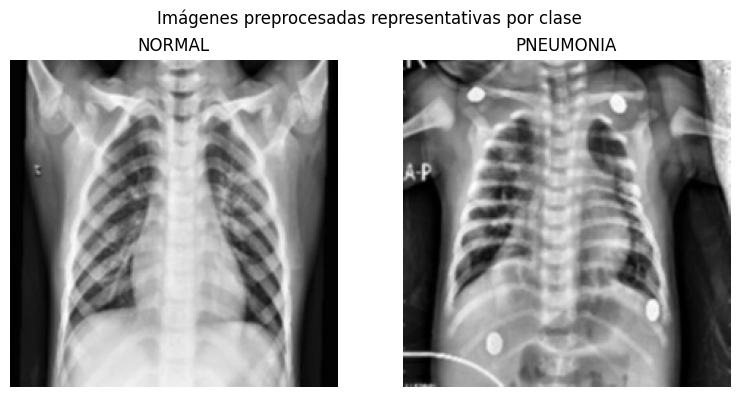

In [ ]:
# ============================================
# 6. VISUALIZAR IMÁGENES REPRESENTATIVAS POR CLASE
# ============================================

def mostrar_imagen(path, titulo):
    image, _ = cargar_imagen(path, 0)

    plt.imshow(tf.squeeze(image), cmap='gray')
    plt.title(titulo)
    plt.axis('off')

normal_example = X_train[y_train.index(0)]
pneumonia_example = X_train[y_train.index(1)]

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
mostrar_imagen(normal_example, "NORMAL")

plt.subplot(1, 2, 2)
mostrar_imagen(pneumonia_example, "PNEUMONIA")

plt.suptitle("Imágenes preprocesadas representativas por clase")
plt.tight_layout()
plt.show()

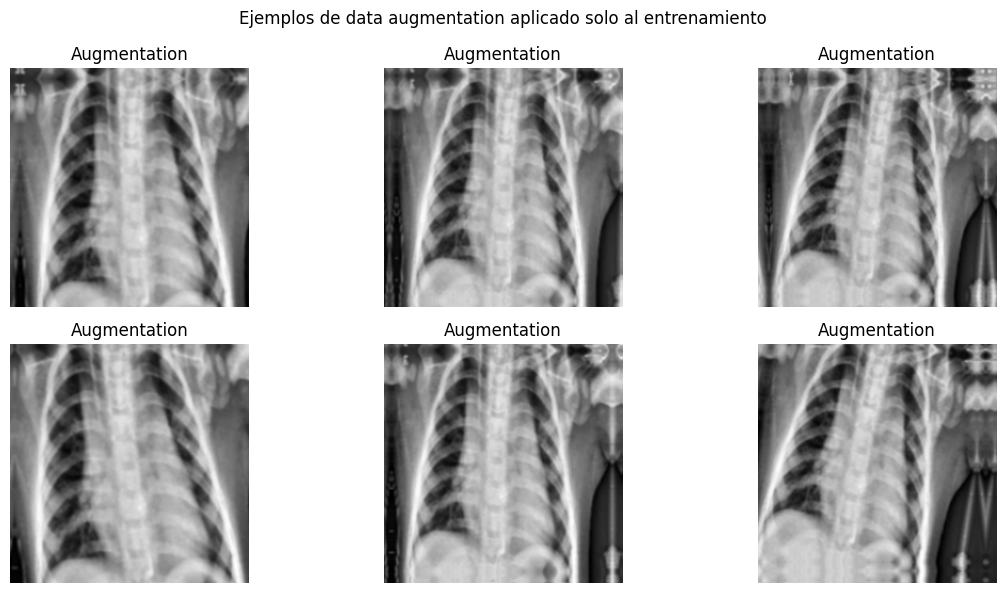

In [ ]:
# ============================================
# 7. DATA AUGMENTATION
# Solo para entrenamiento
# ============================================

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomRotation(0.05),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

for images, labels_batch in train_ds.take(1):
    image = images[0]

    plt.figure(figsize=(12, 6))

    for i in range(6):
        augmented = data_augmentation(tf.expand_dims(image, 0), training=True)

        plt.subplot(2, 3, i + 1)
        plt.imshow(tf.squeeze(augmented[0]), cmap='gray')
        plt.title("Augmentation")
        plt.axis("off")

    plt.suptitle("Ejemplos de data augmentation aplicado solo al entrenamiento")
    plt.tight_layout()
    plt.show()
    break

In [ ]:
# ============================================
# 8. REPRESENTACIÓN FINAL DEL DATO
# ============================================

print("Representación final para Deep Learning")
print("--------------------------------------")
print("Tipo de dato: Imagen médica preprocesada")
print("Modalidad: Radiografía de tórax")
print("Clases: NORMAL y PNEUMONIA")
print("Tamaño final de imagen:", IMG_SIZE, "x", IMG_SIZE)
print("Número de canales: 1")
print("Forma de entrada por imagen:", (IMG_SIZE, IMG_SIZE, 1))
print("Forma de entrada por batch:", (BATCH_SIZE, IMG_SIZE, IMG_SIZE, 1))
print("Normalización aplicada: valores de píxel en rango [0,1]")
print("Etiquetas: 0 = NORMAL, 1 = PNEUMONIA")
print("Data augmentation: aplicado solo al conjunto de entrenamiento")

Representación final para Deep Learning
--------------------------------------
Tipo de dato: Imagen médica preprocesada
Modalidad: Radiografía de tórax
Clases: NORMAL y PNEUMONIA
Tamaño final de imagen: 224 x 224
Número de canales: 1
Forma de entrada por imagen: (224, 224, 1)
Forma de entrada por batch: (32, 224, 224, 1)
Normalización aplicada: valores de píxel en rango [0,1]
Etiquetas: 0 = NORMAL, 1 = PNEUMONIA
Data augmentation: aplicado solo al conjunto de entrenamiento


In [ ]:
# ============================================
# 9. ARQUITECTURA PRELIMINAR MEJORADA
# No se entrena todavía
# ============================================

modelo_preliminar = tf.keras.Sequential([

    # Entrada
    tf.keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 1)),

    # Data augmentation
    data_augmentation,

    # Bloque convolucional 1
    tf.keras.layers.Conv2D(
        32,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.MaxPooling2D(),

    # Bloque convolucional 2
    tf.keras.layers.Conv2D(
        64,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.MaxPooling2D(),

    # Bloque convolucional 3
    tf.keras.layers.Conv2D(
        128,
        (3,3),
        activation='relu',
        padding='same'
    ),
    tf.keras.layers.MaxPooling2D(),

    # Mucho mejor que Flatten()
    tf.keras.layers.GlobalAveragePooling2D(),

    # Capa densa
    tf.keras.layers.Dense(
        128,
        activation='relu'
    ),

    # Evita sobreajuste
    tf.keras.layers.Dropout(0.30),

    # Salida binaria
    tf.keras.layers.Dense(
        1,
        activation='sigmoid'
    )
])

modelo_preliminar.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 224, 224, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,313 (427.00 KB)

 Trainable params: 109,313 (427.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
print("Distribución de clases:", Counter(labels))

Distribución de clases: Counter({1: 390, 0: 234})
